In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Parameters
# ============================================================

mu_x0 = 3.0
var_x0 = 0.4
sigma_base = 2.0
var_z0 = var_x0 + sigma_base**2  # 4.4


sigma_base = 2
data='gaussian'  # 'gaussian' or 'mixture'
n_samples = 30000



# Mixture parameters for X_0
mixture_weights = torch.tensor([0.5, 0.5], device=device)
mixture_means = torch.tensor([1, 5.0], device=device)
mixture_stds = torch.tensor([0.4, 0.4], device=device)


def sample_x0_mixture(batch_size):
    """
    Sample hidden clean latent X_0 from a 1D Gaussian mixture.

        X_0 ~ sum_k pi_k N(mu_k, std_k^2)
    """

    # sample component indices
    comp_ids = torch.multinomial(
        mixture_weights,
        num_samples=batch_size,
        replacement=True
    )

   
    means = mixture_means[comp_ids].reshape(batch_size, 1)
    stds = mixture_stds[comp_ids].reshape(batch_size, 1)

    # sample from selected Gaussian component
    x0 = means + stds * torch.randn(batch_size, 1, device=device)

    return x0

def sample_x0(batch_size, mu_x=3.0, var_x=0.4):
    std_x = torch.sqrt(torch.tensor(var_x, device=device))
    x0 = mu_x + std_x * torch.randn(batch_size, 1, device=device)
    return x0


def sample_z0_from_x0(x0):
    """
    Observation model:
    
        Z_0 = X_0 + sigma * eps_0
    """
    eps0 = torch.randn_like(x0)
    z0 = x0 + sigma_base * eps0
    return z0


def sample_joint_data(batch_size, data):
    """
    Return both hidden X_0 and observed Z_0.
    """
    if data == 'mixture':
        x0 = sample_x0_mixture(batch_size)
    else:
        x0 = sample_x0(batch_size, mu_x=3.0, var_x=0.4)
    z0 = sample_z0_from_x0(x0)
    return x0, z0


def sample_data(batch_size, data=data):
    """
    The DDPM only observes Z_0.
    """
    _, z0 = sample_joint_data(batch_size, data=data)
    return z0

# Choix simple pour tester avec sigma_t^2 = sigma^2 / 2^t
T = 20

betas = torch.full((T,), 0.5, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))


def sigma2_t(t, x_shape):
    """
    sigma_t^2 = sigma_base^2 / 2^t
    """
    out = sigma_base**2 / (2.0 ** t.float())
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

def extract_sigma2(t, x_shape):
    """
    Return sigma_t^2 reshaped for broadcasting.
    """
    out = sigma2_t(t, x_shape)
    return out.reshape(-1, *([1] * (len(x_shape) - 1)))
def extract_alpha_bar_prev(t, x_shape):
    """
    Return alpha_bar_{t-1}.
    For t=0, alpha_bar_{-1} is interpreted as 1,
    because X_{t-1}=X_0 at the final step.
    """
    out = torch.ones_like(t, dtype=torch.float, device=t.device)

    mask = t > 0
    if mask.any():
        out[mask] = alpha_bars.gather(0, t[mask] - 1)

    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

In [12]:
@torch.no_grad()
def true_score_z_gaussian(zt, t):
    """
    True score of Z_t for:
        X0 ~ N(3, 0.4)
        Z0 = X0 + sigma_base * eps
        sigma_base = 2
    """

    mu_x0 = 3.0
    var_x0 = 0.4
    var_z0 = var_x0 + sigma_base**2  # = 4.4 if sigma_base=2

    alpha_bar_t = extract(alpha_bars, t, zt.shape)

    mu_z_t = mu_x0 * torch.sqrt(alpha_bar_t)
    var_z_t = alpha_bar_t * var_z0 + (1.0 - alpha_bar_t)

    score = -(zt - mu_z_t) / var_z_t

    return score

In [13]:
@torch.no_grad()
def p_sample_hidden_x_true_score(zt, t, eta):
    """
    Same sampler as yours, but using the true Gaussian score of Z_t.
    """

    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)

    # sigma_{t-1}^2
    sigma_prev2 = extract_sigma2(t, zt.shape)

    # delta_t = beta_t + alpha_t * sigma_{t-1}^2
    delta_t = beta_t + alpha_t * sigma_prev2

    # True score of f_t^Z
    score = true_score_z_gaussian(zt, t)

    # Tweedie estimate: mean of X_{t-1} | Z_t
    x_prev_hat = (zt + delta_t * score) / torch.sqrt(alpha_t)

    # Your stochasticity parameter
    noise_x = torch.randn_like(zt)
    x_prev = x_prev_hat + eta * noise_x

    # Z_{t-1} | X_{t-1}, Z_t
    mean_z = (
        x_prev
        +
        (torch.sqrt(alpha_t) * sigma_prev2 / delta_t)
        * (zt - torch.sqrt(alpha_t) * x_prev)
    )

    var_z = sigma_prev2 * beta_t / delta_t

    noise_z = torch.randn_like(zt)
    z_prev = mean_z + torch.sqrt(var_z) * noise_z

    return z_prev, x_prev, x_prev_hat, mean_z, var_z

In [14]:
@torch.no_grad()
def sample_hidden_x_from_z_ddpm( n_samples, eta):
    """
    Full adapted reverse chain.

    Returns:
        x0_hat    : generated latent X_0
        z0_hat    : generated observed Z_0
        trajectory: selected intermediate states
    """
  
    zt = torch.randn(n_samples, 1, device=device)

    trajectory = []
    x_prev_hat = None

    for time_step in reversed(range(T)):
        t = torch.full((n_samples,), time_step, device=device, dtype=torch.long)

        z_prev, x_prev, x_prev_hat, mean_z, var_z= p_sample_hidden_x_true_score( zt, t, eta)

        if time_step in [T - 1, 200, 100, 50, 10, 0]:
            trajectory.append(
                {
                    "time": time_step,
                    "z_t": zt.detach().cpu(),
                    "x_prev": x_prev.detach().cpu(),
                    "x_prev_hat": x_prev_hat.detach().cpu(),
                    "z_prev": z_prev.detach().cpu(),
                    "var_z": var_z.detach().cpu(),
                }
            )

        zt = z_prev

    z0_hat = zt.detach().cpu()
    x0_hat = x_prev.detach().cpu()

    return x0_hat, z0_hat, trajectory

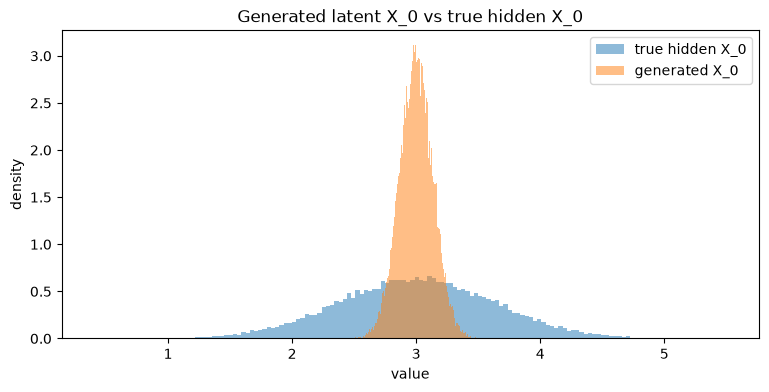

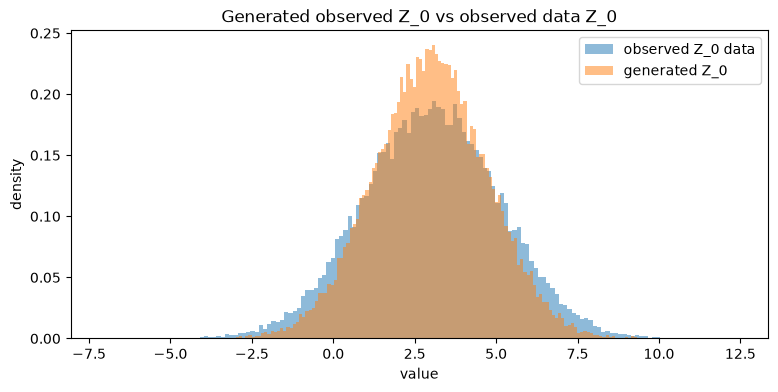

In [ ]:
x0_gen, z0_gen, trajectory = sample_hidden_x_from_z_ddpm( n_samples=30000, eta=0)

x0_real, z0_real = sample_joint_data(30000, data=data)
x0_real = x0_real.detach().cpu()
z0_real = z0_real.detach().cpu()

plt.figure(figsize=(9, 4))
plt.hist(x0_real.numpy(), bins=150, density=True, alpha=0.5, label="true hidden X_0")
plt.hist(x0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated X_0")
plt.title("Generated latent X_0 vs true hidden X_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(z0_real.numpy(), bins=150, density=True, alpha=0.5, label="observed Z_0 data")
plt.hist(z0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated Z_0")
plt.title("Generated observed Z_0 vs observed data Z_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

Autre test avec ajouter du bruit

In [ ]:
@torch.no_grad()
def p_sample_hidden_x_true_score_simple(zt, t, eta):
    """
    Same sampler as yours, but using the true Gaussian score of Z_t.
    """

    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)

    # sigma_{t-1}^2
    sigma_prev2 = extract_sigma2(t, zt.shape)

    # delta_t = beta_t + alpha_t * sigma_{t-1}^2
    delta_t = beta_t + alpha_t * sigma_prev2

    # True score of f_t^Z
    score = true_score_z_gaussian(zt, t)

    # Tweedie estimate: mean of X_{t-1} | Z_t
    x_prev_hat = (zt + delta_t * score) / torch.sqrt(alpha_t)

    # Your stochasticity parameter
    noise_x = torch.randn_like(zt)
    x_prev = x_prev_hat + eta * noise_x

    # Z_{t-1} | X_{t-1}, Z_t


    noise_z = torch.randn_like(zt)
    z_prev = x_prev + torch.sqrt(sigma_prev2) * noise_z

    return z_prev, x_prev, x_prev_hat

In [21]:
@torch.no_grad()
def sample_hidden_x_from_z_ddpm( n_samples, eta):
    """
    Full adapted reverse chain.

    Returns:
        x0_hat    : generated latent X_0
        z0_hat    : generated observed Z_0
        trajectory: selected intermediate states
    """
  
    zt = torch.randn(n_samples, 1, device=device)

    trajectory = []
    x_prev_hat = None

    for time_step in reversed(range(T)):
        t = torch.full((n_samples,), time_step, device=device, dtype=torch.long)

        z_prev, x_prev, x_prev_hat= p_sample_hidden_x_true_score_simple( zt, t, eta)

        if time_step in [T - 1, 200, 100, 50, 10, 0]:
            trajectory.append(
                {
                    "time": time_step,
                    "z_t": zt.detach().cpu(),
                    "x_prev": x_prev.detach().cpu(),
                    "x_prev_hat": x_prev_hat.detach().cpu(),
                    "z_prev": z_prev.detach().cpu(),
                }
            )

        zt = z_prev

    z0_hat = zt.detach().cpu()
    x0_hat = x_prev.detach().cpu()

    return x0_hat, z0_hat, trajectory

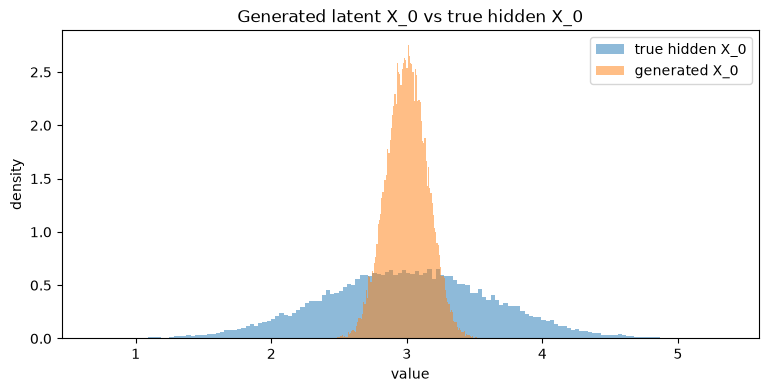

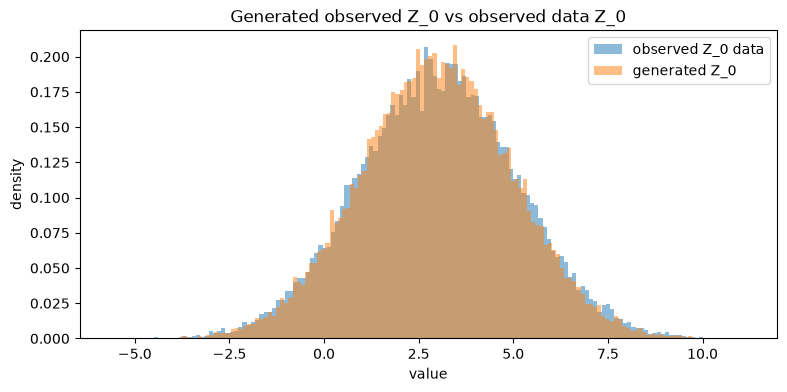

In [22]:
x0_gen, z0_gen, trajectory = sample_hidden_x_from_z_ddpm( n_samples=30000, eta=0)

x0_real, z0_real = sample_joint_data(30000, data=data)
x0_real = x0_real.detach().cpu()
z0_real = z0_real.detach().cpu()

plt.figure(figsize=(9, 4))
plt.hist(x0_real.numpy(), bins=150, density=True, alpha=0.5, label="true hidden X_0")
plt.hist(x0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated X_0")
plt.title("Generated latent X_0 vs true hidden X_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(z0_real.numpy(), bins=150, density=True, alpha=0.5, label="observed Z_0 data")
plt.hist(z0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated Z_0")
plt.title("Generated observed Z_0 vs observed data Z_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()